In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from sklearn.model_selection import train_test_split
from torch.optim import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import random
import os

from pathlib import Path
FIGURES_DIR = Path('../artifacts/nn_log/')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [2]:
import mlflow
import mlflow.pytorch

mlflow.set_tracking_uri("./mlruns")
mlflow.set_experiment("Credit_Prediction_Experiments_NN_log")

z:\projects\AIE\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
z:\projects\AIE\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:z:/projects/AIE/project/notebooks/mlruns/784441978176066938', creation_time=1778325955613, experiment_id='784441978176066938', last_update_time=1778325955613, lifecycle_stage='active', name='Credit_Prediction_Experiments_NN_log', tags={}, trace_location=None, workspace='default'>

In [2]:
df = pd.read_csv('../data/CreditPrediction.csv')
df = df.drop(columns=['CLIENTNUM', 'Unnamed: 19'])
df = df[(df['Customer_Age'] <= 80)]
print(f'Размер данных после удаления аномалий: {df.shape[0]}')

Размер данных после удаления аномалий: 10150


In [3]:
target_col = "Credit_Limit"
num_cols = [col for col in df.select_dtypes(include=['int64', 'float64']).columns if col != target_col]
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(num_cols)
print(cat_cols)

['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


In [4]:
print(f'Уникальные значения для категориальных колонок:')

for col_name in cat_cols:
    print(f'{col_name} - {df[col_name].unique()}', end='\n\n')

Уникальные значения для категориальных колонок:
Gender - ['M' 'F' nan]

Education_Level - ['High School' 'Graduate' 'Uneducated' 'Unknown' 'College' 'Post-Graduate'
 'Doctorate']

Marital_Status - ['Married' nan 'Unknown' 'Single' 'Divorced']

Income_Category - ['$60K - $80K' 'Less than $40K' '$80K - $120K' '$40K - $60K' '$120K +'
 'Unknown']

Card_Category - ['Blue' nan 'Gold' 'Silver' 'Platinum']



In [5]:
for col_name in cat_cols:
    df[col_name] = df[col_name].fillna('Unknown')

for col_name in num_cols:
    df[col_name] = df[col_name].fillna(df[col_name].median())

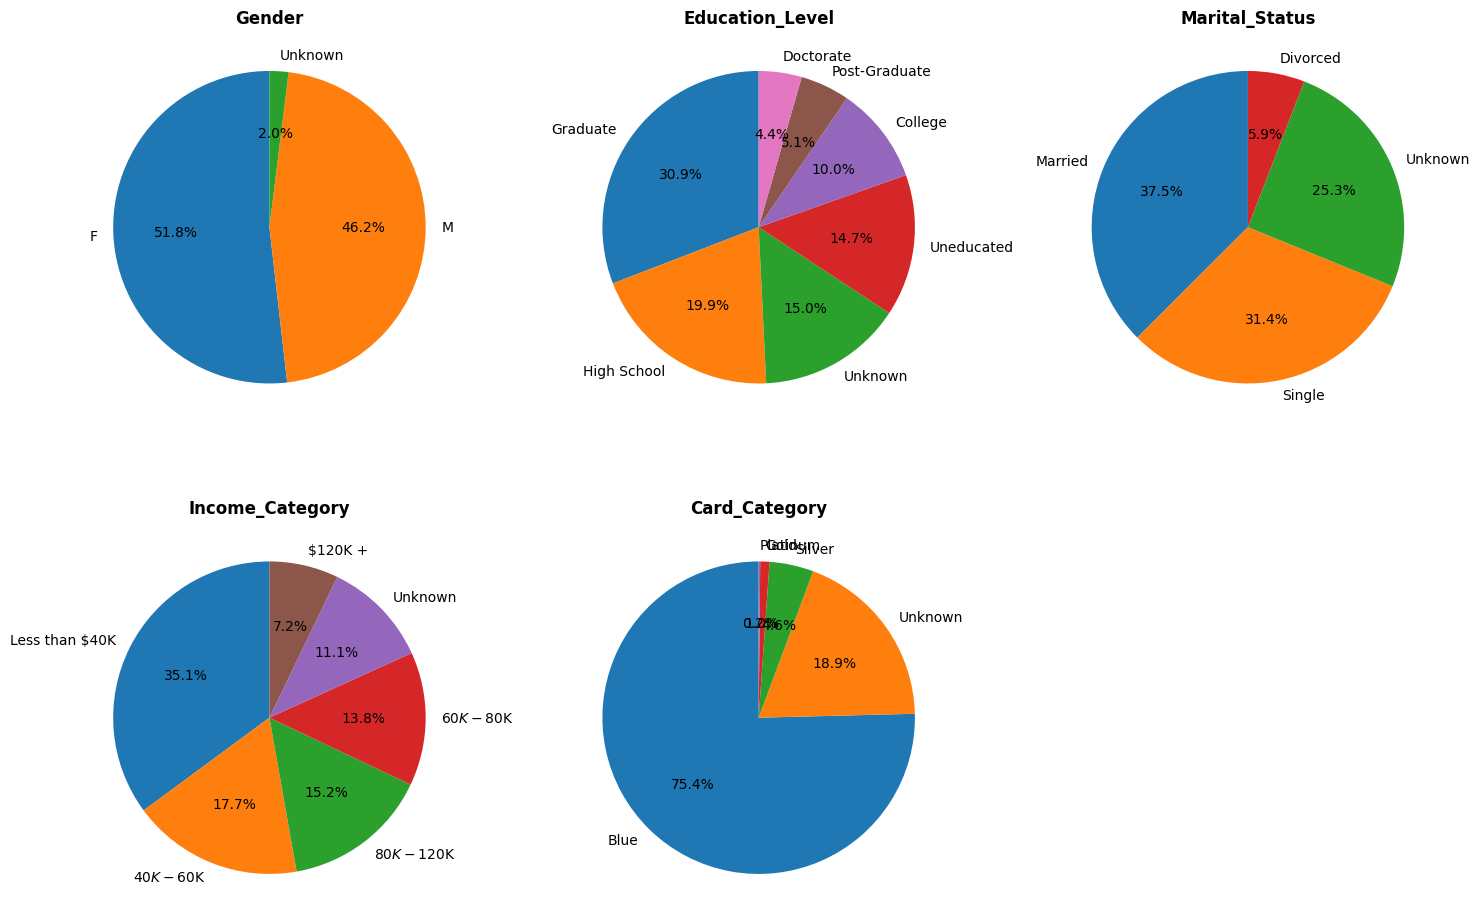

In [6]:
n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for idx, col_name in enumerate(cat_cols):
    value_counts = df[col_name].value_counts()
    axes[idx].pie(value_counts, labels=value_counts.index, autopct='%1.1f%%', startangle=90)
    axes[idx].set_title(col_name, fontsize=12, fontweight='bold')

for idx in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

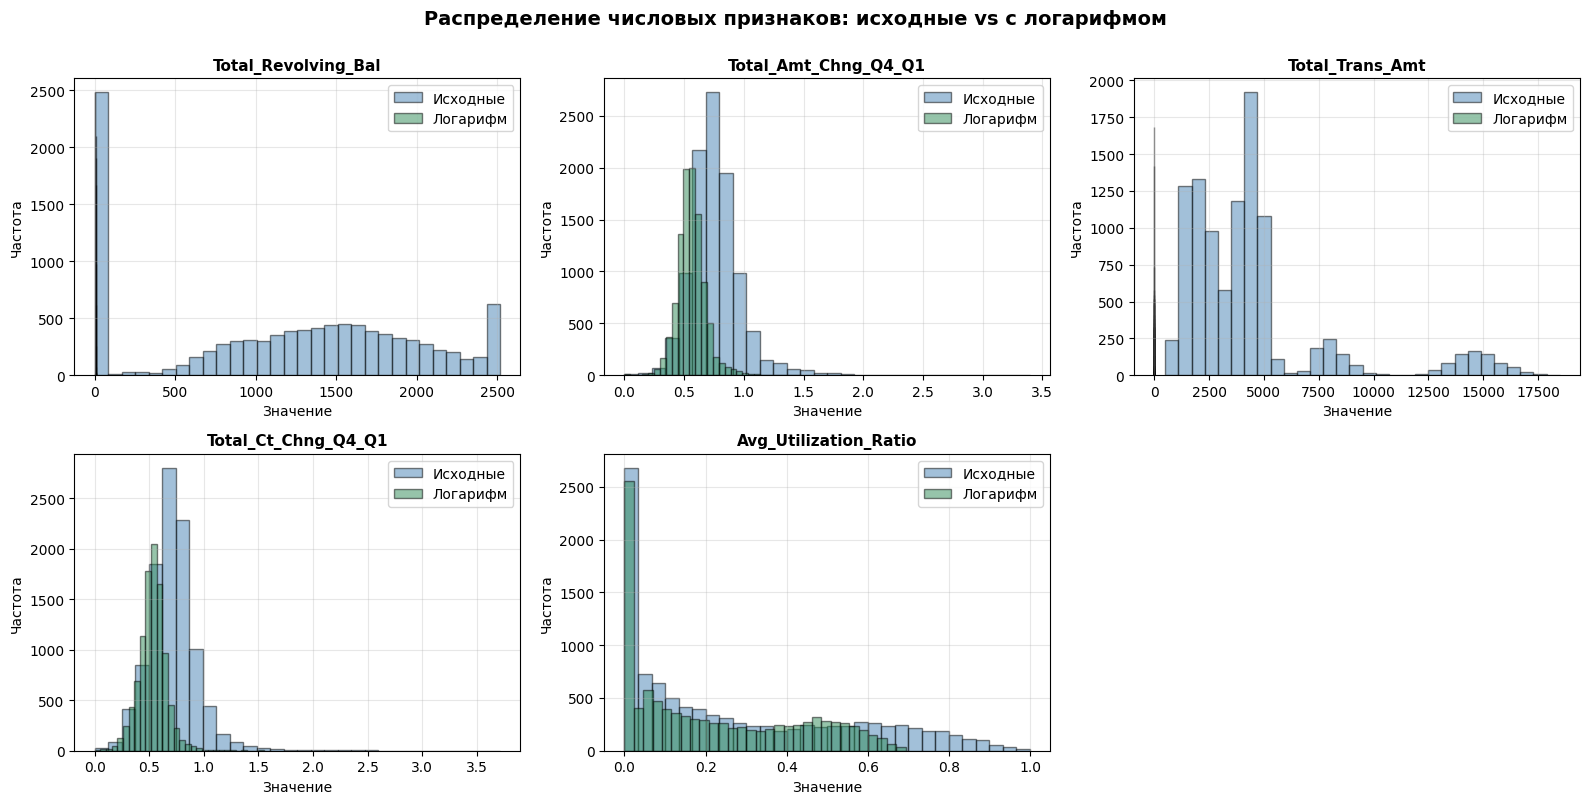

In [ ]:
cols_to_log = ['Total_Revolving_Bal', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

n_cols_hist = 3
n_rows_hist = (len(cols_to_log) + n_cols_hist - 1) // n_cols_hist

fig, axes = plt.subplots(n_rows_hist, n_cols_hist, figsize=(16, 4 * n_rows_hist))
axes = axes.flatten()

for idx, col_name in enumerate(cols_to_log):
    axes[idx].hist(df[col_name], bins=30, alpha=0.5, color='steelblue', edgecolor='black', label='Исходные')
    axes[idx].hist(np.log1p(df[col_name]), bins=30, alpha=0.5, color='seagreen', edgecolor='black', label='Логарифм')
    axes[idx].set_title(f'{col_name}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Значение')
    axes[idx].set_ylabel('Частота')
    axes[idx].grid(alpha=0.3)
    axes[idx].legend()

for idx in range(len(cols_to_log), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Распределение числовых признаков: исходные vs с логарифмом', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
out = FIGURES_DIR / "original_vs_logarithm.png"
plt.savefig(out, bbox_inches='tight')
plt.show()

In [8]:
X = df.drop(columns=[target_col])
y = df[target_col]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f'Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)')

Train: 6090 (60.0%)
Validation: 2030 (20.0%)
Test: 2030 (20.0%)


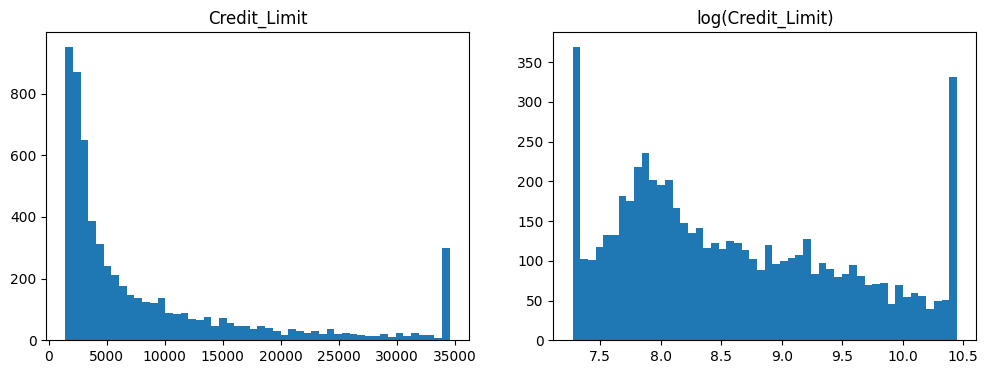

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
y_train_log = np.log(y_train.values)
axes[0].hist(y_train, bins=50); axes[0].set_title('Credit_Limit')
axes[1].hist(y_train_log, bins=50); axes[1].set_title('log(Credit_Limit)')
out = FIGURES_DIR / "original_vs_logarithm_target.png"
plt.savefig(out, bbox_inches='tight')
plt.show()

In [ ]:
import joblib
from category_encoders import TargetEncoder

traget_logged = False
for col in cols_to_log:
    if col in X_train.columns:
        X_train[col] = np.log1p(X_train[col])
        X_val[col] = np.log1p(X_val[col])
        X_test[col] = np.log1p(X_test[col])

# # Отдельно логарифмируем таргет
# y_train = np.log(y_train)
# y_val   = np.log(y_val)
# y_test  = np.log(y_test)
# traget_logged = True

encoder = TargetEncoder(cols=cat_cols, smoothing=10.0, handle_unknown='value')

X_train_enc = encoder.fit_transform(X_train, y_train)
X_val_enc = encoder.transform(X_val)
X_test_enc = encoder.transform(X_test)

joblib.dump(encoder, "../artifacts/target_encoder_nn_base_log.pkl")

['../artifacts/target_encoder_nn_base_log.pkl']

In [10]:
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# scaler = RobustScaler()
X_train_scaled = X_train_enc.copy()
X_train_scaled = scaler.fit_transform(X_train_enc)

X_val_scaled = X_val_enc.copy()
X_val_scaled = scaler.transform(X_val_enc)

X_test_scaled = X_test_enc.copy()
X_test_scaled = scaler.transform(X_test_enc)

In [13]:
X_train_scaled.shape

(6090, 17)

In [11]:
X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)

X_val_tensor = torch.FloatTensor(X_val_scaled)
y_val_tensor = torch.FloatTensor(y_val.values).reshape(-1, 1)

X_test_tensor = torch.FloatTensor(X_test_scaled)
y_test_tensor = torch.FloatTensor(y_test.values).reshape(-1, 1)

In [12]:
BATCH_SIZE = 256

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

In [14]:
model = nn.Sequential(
    nn.Linear(17, 64),
    # nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Linear(64, 64),
    # nn.BatchNorm1d(64),
    nn.ReLU(),
    nn.Linear(64, 1)
).to(device)

from torchinfo import summary
summary(model, input_size=(BATCH_SIZE, 17))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [256, 1]                  --
├─Linear: 1-1                            [256, 64]                 1,152
├─ReLU: 1-2                              [256, 64]                 --
├─Linear: 1-3                            [256, 64]                 4,160
├─ReLU: 1-4                              [256, 64]                 --
├─Linear: 1-5                            [256, 1]                  65
Total params: 5,377
Trainable params: 5,377
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 1.38
Input size (MB): 0.02
Forward/backward pass size (MB): 0.26
Params size (MB): 0.02
Estimated Total Size (MB): 0.30

In [17]:
criterion = nn.MSELoss()
optimizer = Adam(model.parameters(), lr=1e-3)

In [ ]:
def plot_training_progress(train_losses, val_losses, epoch, num_epochs, best_val_loss):
    """Рисует график прогресса обучения"""
    clear_output(wait=True)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(train_losses, c='m', linewidth=2, label='Train Loss')
    ax.plot(val_losses, c='y', linewidth=2, label='Val Loss')
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title(f'Training Progress - Epoch {epoch}/{num_epochs}', fontsize=14, fontweight='bold')
    
    textstr = f'Train Loss (current): {train_losses[-1]:.4f} (best: {min(train_losses):.4f})\n'
    textstr += f'Val Loss (current): {val_losses[-1]:.4f} (best: {best_val_loss:.4f})'
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    ax.legend(loc='upper right', fontsize=11)
    plt.tight_layout()
    out = FIGURES_DIR / "nn_log_training.png"
    plt.savefig(out, bbox_inches='tight')
    display(fig)
    plt.close(fig)

In [19]:
class EarlyStopping:
    def __init__(self, patience=150, min_delta=1e-4):
        """
        Args:
            patience (int): число эпох без улучшения, после которого обучение останавливается
            min_delta (float): минимальное изменение val_loss, которое считается улучшением
        """
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            # значимое улучшение
            self.best_loss = val_loss
            self.counter = 0
        else:
            # нет значимого улучшения
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

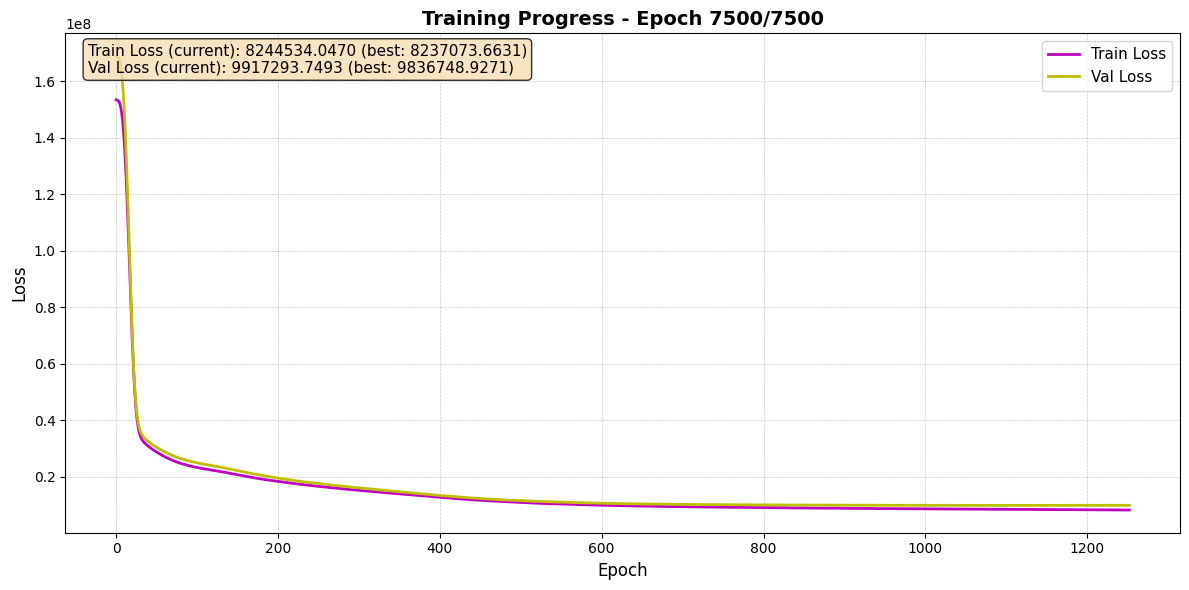

Early stopping triggered at epoch 1252
Лучший лосс на train: 8237073.6631, на val: 9836748.9271
Loaded best model with Val Loss: 9836748.9271
Data hash: 0c491eccf4a9959c9cefab0a27497604


In [ ]:
NUM_EPOCHS = 7500
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_model_state = None

early_stopper = EarlyStopping(patience=150, min_delta=1e-7 if traget_logged else 1e-4)
triggered_epoch = None

for epoch in range(NUM_EPOCHS):
    model.train()
    train_loss = 0
    for x_batch, y_batch in train_dataloader:
        x_batch = x_batch.to(device, non_blocking=True)
        y_batch = y_batch.to(device, non_blocking=True)

        optimizer.zero_grad()
        pred = model(x_batch)
        loss = criterion(pred, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x_batch.shape[0]
    
    train_loss /= len(train_dataset)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x_batch, y_batch in val_dataloader:
            x_batch = x_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)
            
            pred = model(x_batch)
            loss = criterion(pred, y_batch)

            val_loss += loss.item() * x_batch.shape[0]

    val_loss /= len(val_dataset)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss 
        best_model_state = model.state_dict().copy()

    if early_stopper(val_loss):
        triggered_epoch = epoch
        break

    if epoch % 10 == 0:
        plot_training_progress(train_losses, val_losses, epoch, NUM_EPOCHS, best_val_loss)

plot_training_progress(train_losses, val_losses, NUM_EPOCHS, NUM_EPOCHS, best_val_loss)

if triggered_epoch:
    print(f"Early stopping triggered at epoch {triggered_epoch}")

print(f'Лучший лосс на train: {min(train_losses):.4f}, на val: {best_val_loss:.4f}')

if best_model_state is not None:
    torch.save(best_model_state, '../artifacts/model_nn_log_base.pth')
    # model.load_state_dict(torch.load('artifacts/model_best.pth'))
    model.load_state_dict(best_model_state)
    print(f"Loaded best model with Val Loss: {best_val_loss:.4f}")


import json, hashlib

config = {
    "target_col": target_col,
    "num_cols": num_cols,
    "cat_cols": cat_cols,
    "encoder": "TargetEncoder(smoothing=10.0)",
    "scaler": str(scaler)[:-2],
    "batch_size": BATCH_SIZE,
    "optimizer": "Adam",
    "learning_rate": 1e-3,
    "epochs": NUM_EPOCHS,
    "device": str(device),
    "random_state": 42,
    "train_size": len(X_train),
    "val_size": len(X_val),
    "test_size": len(X_test),
    "data_alteration": "Only age<=80, Log of features" + ", Log of target" if traget_logged else "",
    "architecture": "No BatchNorm",
}

with open("../artifacts/NN_mlflow/nn_log_config.json", "w") as f:
    json.dump(config, f, indent=2)

data_path = "../data/CreditPrediction.csv"
with open(data_path, "rb") as f:
    data_hash = hashlib.md5(f.read()).hexdigest()
print(f"Data hash: {data_hash}")

In [18]:
model.load_state_dict(torch.load('../artifacts/model_nn_log_base.pth'))

<All keys matched successfully>

In [ ]:
model.eval()
with torch.no_grad():
    X_train_device = X_train_tensor.to(device)
    y_train_device = y_train_tensor.to(device)
    y_train_pred_nn = model(X_train_device).cpu().numpy()
    y_train_actual = y_train_device.cpu().numpy()
    if traget_logged:
        y_train_pred_nn = np.exp(y_train_pred_nn)
        y_train_actual = np.exp(y_train_actual)
    
    X_val_device = X_val_tensor.to(device)
    y_val_device = y_val_tensor.to(device)
    y_val_pred_nn = model(X_val_device).cpu().numpy()
    y_val_actual = y_val_device.cpu().numpy()
    if traget_logged:
        y_val_pred_nn = np.exp(y_val_pred_nn)
        y_val_actual = np.exp(y_val_actual)
    
    X_test_device = X_test_tensor.to(device)
    y_test_device = y_test_tensor.to(device)
    y_test_pred_nn = model(X_test_device).cpu().numpy()
    y_test_actual = y_test_device.cpu().numpy()
    if traget_logged:
        y_test_pred_nn = np.exp(y_test_pred_nn)
        y_test_actual = np.exp(y_test_actual)

def calculate_nn_metrics(y_true, y_pred, dataset_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'\n{dataset_name}:')
    print(f'  MSE:  {mse:.4f}')
    print(f'  RMSE: {rmse:.4f}')
    print(f'  MAE:  {mae:.4f}')
    print(f'  R²:   {r2:.4f}')
    
    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

print('=' * 50)
print('Метрики Neural Network модели')
print('=' * 50)

train_nn_metrics = calculate_nn_metrics(y_train_actual, y_train_pred_nn, 'TRAIN')
val_nn_metrics = calculate_nn_metrics(y_val_actual, y_val_pred_nn, 'VALIDATION')
test_nn_metrics = calculate_nn_metrics(y_test_actual, y_test_pred_nn, 'TEST')

print('\n' + '=' * 50)

Метрики Neural Network модели

TRAIN:
  MSE:  8209612.0000
  RMSE: 2865.2420
  MAE:  1213.2173
  R²:   0.8986

VALIDATION:
  MSE:  9917294.0000
  RMSE: 3149.1735
  MAE:  1383.5372
  R²:   0.8863

TEST:
  MSE:  8801033.0000
  RMSE: 2966.6535
  MAE:  1317.1907
  R²:   0.8932



In [ ]:
with mlflow.start_run(run_name="NN_baseline_log"):
    
    mlflow.log_params(config)
    mlflow.log_param("data_hash", data_hash)
    
    mlflow.log_metrics({
        "train_mse": train_nn_metrics["MSE"],
        "train_rmse": train_nn_metrics["RMSE"],
        "train_mae": train_nn_metrics["MAE"],
        "train_r2": train_nn_metrics["R2"],
        "val_mse": val_nn_metrics["MSE"],
        "val_rmse": val_nn_metrics["RMSE"],
        "val_mae": val_nn_metrics["MAE"],
        "val_r2": val_nn_metrics["R2"],
        "test_mse": test_nn_metrics["MSE"],
        "test_rmse": test_nn_metrics["RMSE"],
        "test_mae": test_nn_metrics["MAE"],
        "test_r2": test_nn_metrics["R2"],
    })
    
    mlflow.pytorch.log_model(model, "model")
    
    mlflow.log_artifact("../artifacts/nn_log_config.json")
    mlflow.log_artifact(data_path, "data")

2026/05/09 16:41:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/09 16:41:57 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/09 16:41:57 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.1+cu118) contains a local version label (+cu118). MLflow logged a pip requirement for this package as 'torch==2.7.1' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/09 16:42:01 WARNING mlflow.utils.requirements_utils: Found torch version (2.7.1+cu118) contains a local version label (+

In [29]:
X_train_tensor = X_train_tensor.cpu()
X_val_tensor = X_val_tensor.cpu()
X_test_tensor = X_test_tensor.cpu()
model.cpu()
y_train_pred = model(X_train_tensor)
y_val_pred = model(X_val_tensor)
y_test_pred = model(X_test_tensor)

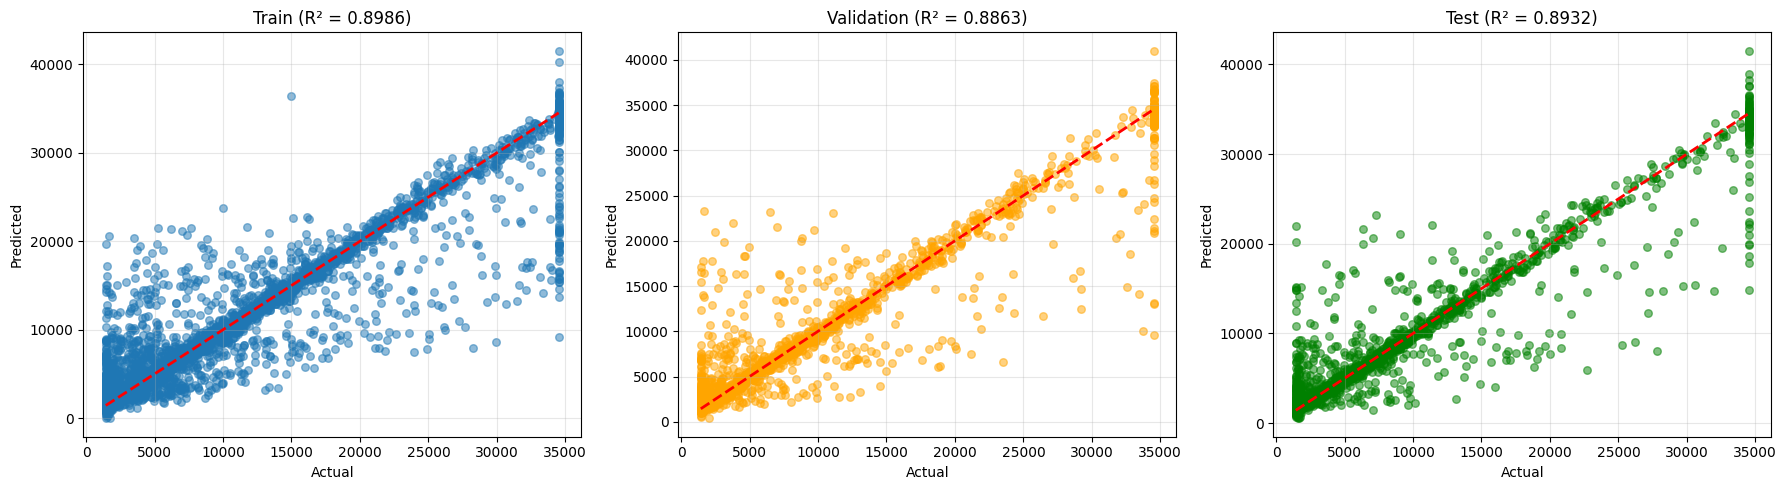

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_train, y_train_pred.detach().numpy(), alpha=0.5, s=30)
axes[0].plot([y_train.min(), y_train.max()], 
             [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Train (R² = {train_nn_metrics["R2"]:.4f})')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_val, y_val_pred.detach().numpy(), alpha=0.5, s=30, color='orange')
axes[1].plot([y_val.min(), y_val.max()], 
             [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title(f'Validation (R² = {val_nn_metrics["R2"]:.4f})')
axes[1].grid(True, alpha=0.3)

axes[2].scatter(y_test, y_test_pred.detach().numpy(), alpha=0.5, s=30, color='green')
axes[2].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title(f'Test (R² = {test_nn_metrics["R2"]:.4f})')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
out = FIGURES_DIR / "nn_log_best.png"
plt.savefig(out, bbox_inches='tight')
plt.show()
